# DSCI 235 Final Project - Stanley Cup Playoffs Analysis

Github:

## Introduction

Over the last few years I had been getting more and more into hockey, so I figured I could have a little fun and analyse a bit of old Stanley Cup Playoff data. The data I found for this project has every Stanley Cup Playoff team, their record, goals for and against, and their rank at the end of the tournament (unfortuneately there was no easily available data on seeding). Data started from 1926 and was taken until 2022. I also added another data set with regular season records for every team, but I'll explain a little more about that when we get there.

Link to original data: https://www.kaggle.com/datasets/mattop/nhl-stanley-cup-playoffs-1918-2022?resource=download

## Loading and Cleaning the Data

Below are the first steps to any coding project, loading your information. I'm only using three packages, with the fourth one only being used to ignore warnings that kept popping up. Below is the dataset I will be using. I did have to clean up the data, namely replace one year since it was wrong and adjust what year I would start using data from. I chose 1927 since, before 1926, non-NHL teams were also competing for the cup and I chose to leave out 1926 since there were only 3 teams in those playoffs and I felt they would make the analysis needlessly skewed.

In [304]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None)

In [305]:
playoffs = pd.read_csv("C:/Users/kurtg/Downloads/nhlplayoffs.csv")
playoffs.loc[704, 'year'] = 1977
playoffs = playoffs.loc[playoffs['year'] >= 1927]

This next big chunk is to add one new column stating which round a team exitted the platoffs in. the original dataset only has the "ranks," which don't mean too much in this case since this is a tournament and not a round robin. Multiple teams will be eliminated each round and it's hard to rank one team over another when they haven't played each other.

In [506]:
#This section is to add in a column that describes which round in the playoffs a team loses in

playoffs['num_teams'] = playoffs.groupby('year')['team'].transform('count')

playoffs['round'] = np.select(
    [
        # Winners / finalists
        playoffs['rank'] == 1,
        playoffs['rank'] == 2,

        # --- 12 TEAM SPECIAL CASE ---
        (playoffs['num_teams'] == 12) & (playoffs['rank'] >= 9),   # bottom 4
        (playoffs['num_teams'] == 12) & (playoffs['rank'].between(5, 8)),
        (playoffs['num_teams'] == 12) & (playoffs['rank'].between(3, 4)),

        # 6 team special case
        (playoffs['num_teams'] == 6) & (playoffs['rank'] >= 5),
        (playoffs['num_teams'] == 6) & (playoffs['rank'].between(3, 4)),
        
        # --- STANDARD FORMATS ---
        ((playoffs['num_teams'] != 12) & (playoffs['num_teams'] != 6)) & (playoffs['rank'] <= playoffs['num_teams'] // 4),
        ((playoffs['num_teams'] != 12) & (playoffs['num_teams'] != 6)) & (playoffs['rank'] <= playoffs['num_teams'] // 2),
        ((playoffs['num_teams'] != 12) & (playoffs['num_teams'] != 6)) & (playoffs['rank'] <= playoffs['num_teams'])
    ],
    [
        'Won Stanley Cup',
        'Lost Stanley Cup Finals',

        # 12-team labels
        'Lost Round of 12',
        'Lost Quarterfinals',
        'Lost Semi-Finals',

        #6-team labels
        'Lost Quarterfinals',
        'Lost Semi-Finals',
        
        # standard labels
        'Lost Semi-Finals',
        'Lost Quarterfinals',
        'Lost Round of ' + playoffs['num_teams'].astype(str)
    ],
    default=np.nan
)

playoffs.loc[playoffs['num_teams'] == 8, 'round'] = playoffs['round'].replace(
    'Lost Round of 8', 'Lost Quarterfinals'
)

playoffs.loc[playoffs['num_teams'] == 4, 'round'] = playoffs['round'].replace(
    'Lost Round of 4', 'Lost Semi-Finals'
)

playoffs['round'] = pd.Categorical(playoffs['round'])
bins_playoffs = round(np.sqrt(len(playoffs)))
bins_16 = round(np.sqrt(len(playoffs.loc[playoffs['num_teams'] == 16])))
playoffs.head()

,rank,team,year,games,wins,losses,ties,shootout_wins,shootout_losses,win_loss_percentage,goals_scored,goals_against,goal_differential,num_teams,round,ratio_rank,goals_per_game,against_per_game
0,1,Colorado Avalanche,2022,20,16,4,0,5,1,0.800,85,55,30,16,Won Stanley Cup,0.9375,4.250000,2.750000
1,2,Tampa Bay Lightning,2022,23,14,9,0,1,2,0.609,67,61,6,16,Lost Stanley Cup Finals,0.8750,2.913043,2.652174
2,3,New York Rangers,2022,20,10,10,0,1,2,0.500,62,58,4,16,Lost Semi-Finals,0.8125,3.100000,2.900000
3,4,Edmonton Oilers,2022,16,8,8,0,1,2,0.500,65,59,6,16,Lost Semi-Finals,0.7500,4.062500,3.687500
4,5,Carolina Hurricanes,2022,14,7,7,0,1,0,0.500,37,40,-3,16,Lost Quarterfinals,0.6875,2.642857,2.857143


# Question 1: How does playoff record determine outcomes?

This is an admittedly simple question. Obviously the team that wins the Stanley Cup will, most likely, have the best record since they have to win the most games (in a 16 team playoff, they need to win 16 games) inorder to do so. More so, I just want to see how much of a difference between the playoff records between different rounds of the playoffs.

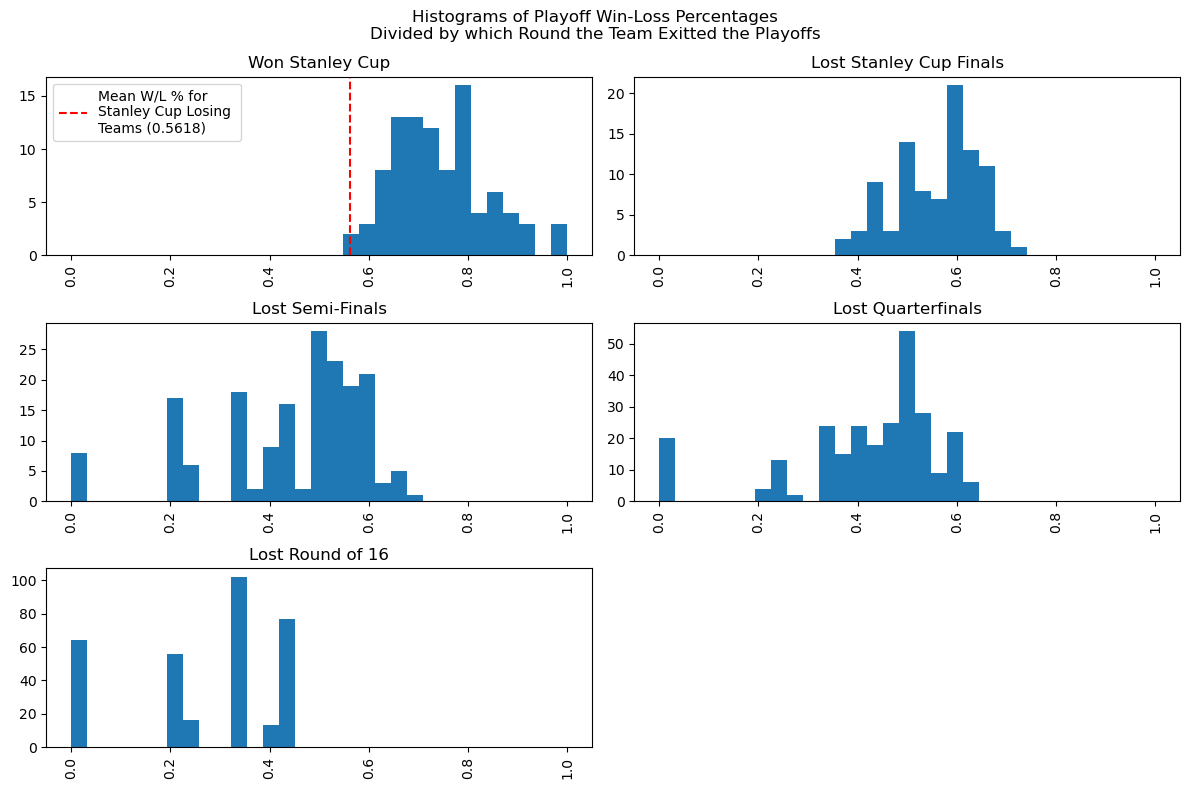

In [451]:
order = ['Won Stanley Cup',
        'Lost Stanley Cup Finals',
        'Lost Semi-Finals',
        'Lost Quarterfinals',
        'Lost Round of 16']

filter = playoffs[(playoffs['round'] != 'Lost Round of 3') & (playoffs['round'] != 'Lost Round of 24') & (playoffs['round'] != 'Lost Round of 12')]
filter['round'] = pd.Categorical(filter['round'], categories=order, ordered=True)
mean_wl_losing = filter.loc[filter['round'] == 'Lost Stanley Cup Finals', 'win_loss_percentage'].mean()

histograms = filter.hist(column='win_loss_percentage',by='round',
                           bins=bins_playoffs, figsize=(12,8), range=(0,1))

ax = histograms.flatten()[0]
ax.axvline(mean_wl_losing, linestyle='--', color='red', label=f'Mean W/L % for \nStanley Cup Losing \nTeams ({mean_wl_losing})')
ax.legend()

fig = histograms.flatten()[0].get_figure()
fig.suptitle('Histograms of Playoff Win-Loss Percentages\nDivided by which Round the Team Exitted the Playoffs') 

plt.tight_layout()
plt.show()

Right away, you can clearly see a trend that teams with better playoff records, naturally, perform much better and go much farther into the playoffs. One thing I find really interesting is how similar most records are between rounds. Losers in the Quarterfinals are floating around a mean playoff record of just over 0.500 (won as many games as they lost) while the average for Stanley Cup Finals Losers is just around there as well (0.562). This 'trend' of very similar playoff records throughout the rounds is completely abandoned by the time we get to the Stanley Cup FInals Winners where few if any teams come close to the mean of the Stanley Cup Finals Runners-Up's playoff record. This indicates that, come playoff season, that a team would be better off steamrolling their opponents than having close series.

Below are some small fun facts that have to do with playoff records:

In [309]:
index = playoffs.loc[playoffs['round'] == 'Won Stanley Cup','win_loss_percentage'].idxmin()
team_worst_rec = playoffs.loc[index,'team']
worst_rec = playoffs.loc[index,'win_loss_percentage']
year_worst_rec = playoffs.loc[index,'year']
print(f'The NHL Team to win the Stanley Cup with the Worst Playoff record is {team_worst_rec} in {year_worst_rec}, with a win-loss percentage of {worst_rec}')

index = playoffs.loc[(playoffs['round'] == 'Won Stanley Cup') & (playoffs['num_teams'] == 16), 'win_loss_percentage'].idxmin()
team_worst_rec = playoffs.loc[index,'team']
worst_rec = playoffs.loc[index,'win_loss_percentage']
year_worst_rec = playoffs.loc[index,'year']
print(f'The NHL Team to win the Stanley Cup with the Worst Playoff record in a 16 team playoff is {team_worst_rec} in {year_worst_rec}, with a win-loss percentage of {worst_rec}')

print()

index = playoffs.loc[playoffs['round'] == 'Won Stanley Cup','win_loss_percentage'].idxmax()
team_worst_rec = playoffs.loc[index,'team']
worst_rec = playoffs.loc[index,'win_loss_percentage']
year_worst_rec = playoffs.loc[index,'year']
print(f'The NHL Team to win the Stanley Cup with the Best Playoff record is {team_worst_rec} in {year_worst_rec}, with a win-loss percentage of {worst_rec}')

index = playoffs.loc[(playoffs['round'] == 'Won Stanley Cup') & (playoffs['num_teams'] == 16), 'win_loss_percentage'].idxmax()
team_worst_rec = playoffs.loc[index,'team']
worst_rec = playoffs.loc[index,'win_loss_percentage']
year_worst_rec = playoffs.loc[index,'year']
print(f'The NHL Team to win the Stanley Cup with the Best Playoff record in a 16 team playoff is {team_worst_rec} in {year_worst_rec}, with a win-loss percentage of {worst_rec}')

print()

index = playoffs.loc[playoffs['round'] == 'Lost Stanley Cup Finals','win_loss_percentage'].idxmax()
losing_team_best = playoffs.loc[index,'team']
losing_best_rec = playoffs.loc[index,'win_loss_percentage']
losing_year_best_rec = playoffs.loc[index,'year']
print(f'The NHL Team to lose the Stanley Cup with the Best Playoff record is {losing_team_best} in {losing_year_best_rec}, with a win-loss percentage of {losing_best_rec}')

The NHL Team to win the Stanley Cup with the Worst Playoff record is Toronto Maple Leafs in 1964, with a win-loss percentage of 0.571
The NHL Team to win the Stanley Cup with the Worst Playoff record in a 16 team playoff is St. Louis Blues in 2019, with a win-loss percentage of 0.615

The NHL Team to win the Stanley Cup with the Best Playoff record is Montreal Canadiens in 1960, with a win-loss percentage of 1.0
The NHL Team to win the Stanley Cup with the Best Playoff record in a 16 team playoff is Edmonton Oilers in 1988, with a win-loss percentage of 0.868

The NHL Team to lose the Stanley Cup with the Best Playoff record is Mighty Ducks of Anaheim in 2003, with a win-loss percentage of 0.714


# Question 2: How does the number of playoff games determine the outcome?

This is sort of similar to the last question, but given that hockey playoffs are in best of 7 series, it is definitely a good one to look into. Baseball, another sport that plays in series, has a lot to do with timing and hand-eye coordination, so taking too much time off from playing can really hurt your chances in performing well since you'll, very quickly, become rusty. Thus, in baseball, it would be beneficial to try and play more games to maintain high performance. Is this a similar effect in hockey, where playing too few games could make you rusty or would playing too many games just be a detriment and tire the players out?

I thought a good way to check this would be to look at the mean number of games between Stanley Cup Final's Winners and Runners Ups. I also selected only from years where there were 16 teams in the playoffs that way the means weren't being skewed too much when htere were only 6 teams in the league.

In [312]:
avg_won_stanley = playoffs.loc[(playoffs['round'] == 'Won Stanley Cup') & (playoffs['num_teams'] >= 16), 'games'].mean()
avg_lost_stanley = playoffs.loc[(playoffs['round'] == 'Lost Stanley Cup Finals') & (playoffs['num_teams'] >= 16), 'games'].mean()

print(f'Average number of Games for teams that Won the Stanley Cup Finals: {round(avg_won_stanley,2)}')
print(f'Average number of Games for teams that Lost the Stanley Cup Finals: {round(avg_lost_stanley,2)}')

Average number of Games for teams that Won the Stanley Cup Finals: 22.1
Average number of Games for teams that Lost the Stanley Cup Finals: 22.05


Shockingly, these means are extremely close together. This could indicate that there isn't too much of a difference in performance nomatter how many games are played. But let's also look at the distribution to see if we can find any other interesting information.

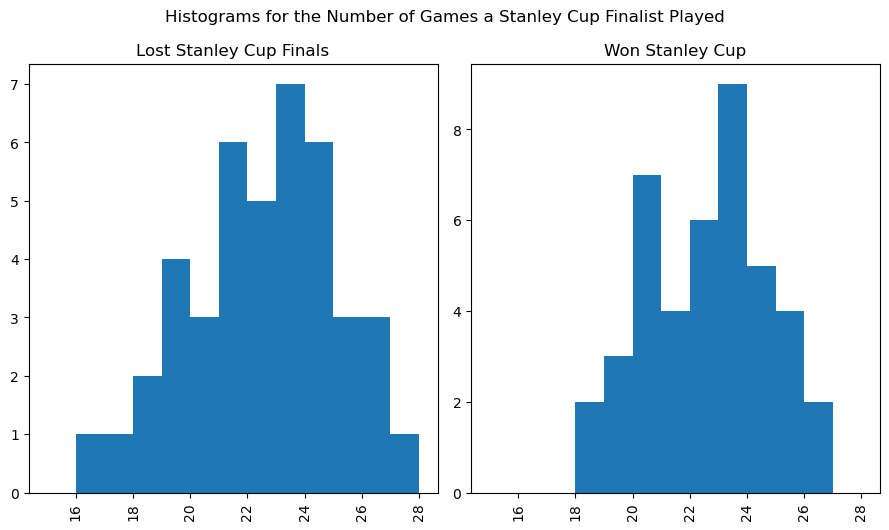

In [516]:
filter2 = playoffs.loc[((playoffs['round'] == 'Won Stanley Cup') | (playoffs['round'] == 'Lost Stanley Cup Finals')) & (playoffs['num_teams'] >= 16)]
filter2['round'] = filter2['round'].cat.remove_unused_categories()

histograms2 = filter2.hist(column='games',by='round',
            bins=round(bins_16/2), figsize=(9,5.5),range=(15,28))

fig = histograms2.flatten()[0].get_figure()
fig.suptitle('Histograms for the Number of Games a Stanley Cup Finalist Played') 

plt.tight_layout()
plt.show()

Like the means, these distributions are very similar to one another. If you look closely, it looks like Stanley Cup Winners ever so slighly play more games (more bulky towards the right end), but I wouldn't say that that indicates playing more games is better or worse for you.

# Question 3: How do goals for and goals against determine outcomes?

Very self explanatory. Like before, most likely the more goals scored and the less goals against will give a very accurate prediction to who will win.

## Goals For

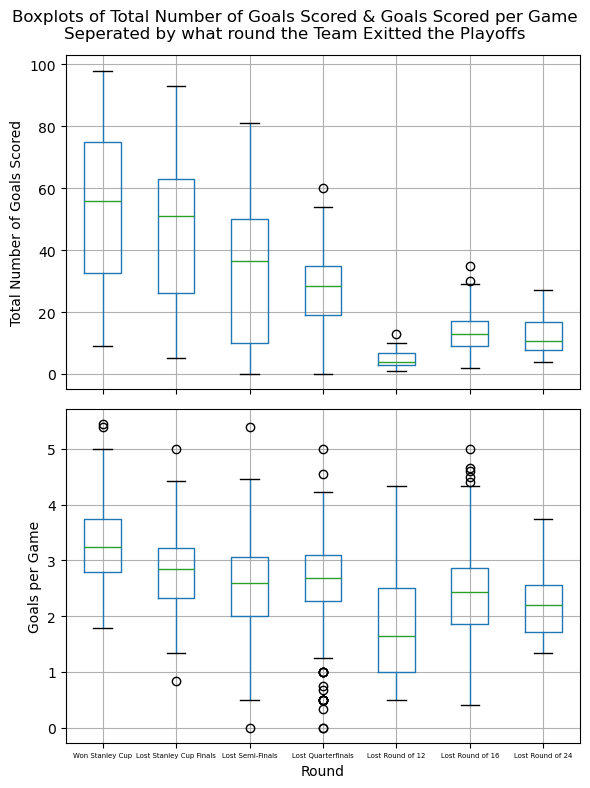

In [461]:
order2 = ['Won Stanley Cup',
        'Lost Stanley Cup Finals',
        'Lost Semi-Finals',
        'Lost Quarterfinals',
          'Lost Round of 12',
        'Lost Round of 16',
         'Lost Round of 24']

playoffs['round'] = playoffs['round'].cat.reorder_categories(order2, ordered=True)
playoffs['goals_per_game'] = playoffs['goals_scored']/playoffs['games']

fig, axes = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

playoffs.boxplot(column='goals_scored',by='round', ax=axes[0])
playoffs.boxplot(column='goals_per_game',by='round', ax=axes[1])

axes[0].set_title('')
axes[1].set_title('')

axes[0].set_xticklabels([])
axes[0].set_xlabel('')
axes[1].set_xlabel('Round')
axes[0].set_ylabel('Total Number of Goals Scored')
axes[1].set_ylabel('Goals per Game')

axes[1].set_xticks(range(1, len(order2) + 1))
axes[1].set_xticklabels(order2, fontsize=5)

fig.suptitle('Boxplots of Total Number of Goals Scored & Goals Scored per Game\nSeperated by what round the Team Exitted the Playoffs')

plt.tight_layout()
plt.show()

The top boxplot is a little dubious as it is obviously easier to score more points when your playing more games. Still though, the assumption is completely upheld as more goals tends to lead to more winning. The second boxplot however is showing similar trends to the histograms regarding Win-Loss Percentages. Between the Quarter-, Semi-, and Finals Runners Up, the medians and even some of the intervals are very similar to one another, suggesting that for these groups, goals scored per game is rather similar. When it comes to Finals Winners, they are clealy outscoring their opponents. About 3/4ths of the winners are scoring the same amount if not more than the median goals/game of the runners up. Infact, the median for Finals Winners is about 0.5 points higher than the other rounds.

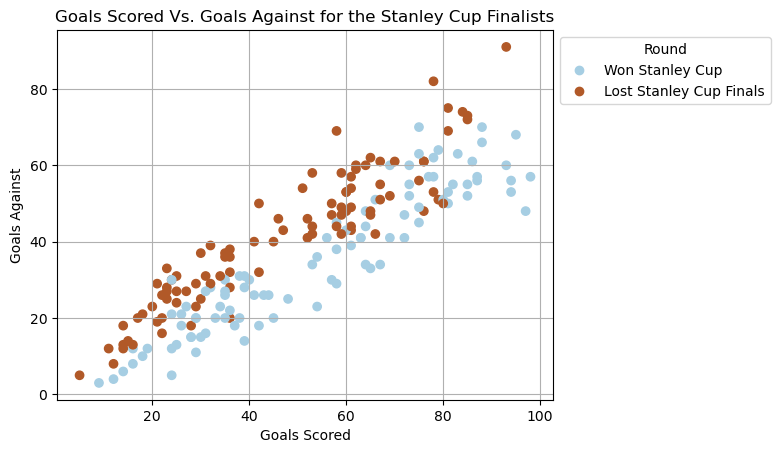

In [467]:
filter5 = playoffs.loc[(playoffs['round'] == 'Won Stanley Cup') | (playoffs['round'] == 'Lost Stanley Cup Finals')]
filter5['round'] = filter5['round'].cat.remove_unused_categories()
filter5['round'] = pd.Categorical(filter5['round'], categories=order, ordered=True)
filter5['round_code'] = filter5['round'].cat.codes

scatter = plt.scatter(filter5['goals_scored'],filter5['goals_against'],
                    c=filter5['round_code'],
                    cmap='Paired')

handles, _ = scatter.legend_elements()
labels = filter5['round'].cat.categories

plt.legend(handles, labels, title='Round',loc='upper left',
           bbox_to_anchor=(1, 1))
plt.title('Goals Scored Vs. Goals Against for the Stanley Cup Finalists')
plt.xlabel('Goals Scored')
plt.ylabel('Goals Against')
plt.grid(True)
plt.show()

Using the above scatter plot, we can see that runners up tend to allow for more points than winners, which would indicate that a better defense is what can win championships.

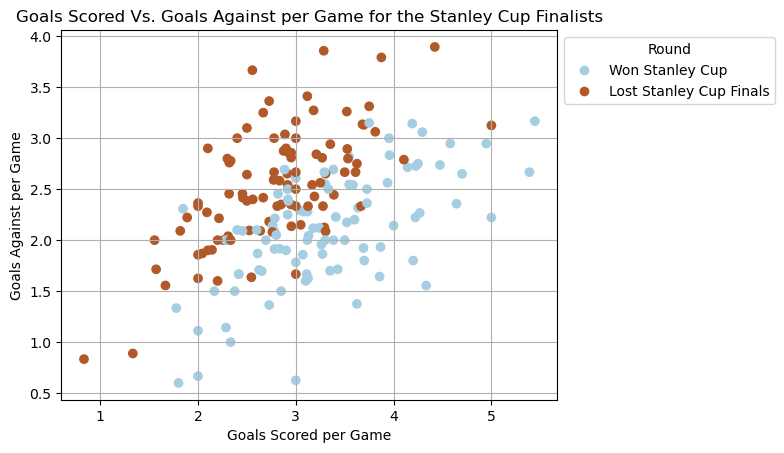

In [469]:
scatter = plt.scatter(filter5['goals_per_game'],filter5['against_per_game'],
                    c=filter5['round_code'],
                    cmap='Paired')

handles, _ = scatter.legend_elements()
labels = filter5['round'].cat.categories

plt.legend(handles, labels, title='Round',loc='upper left',
           bbox_to_anchor=(1, 1))
plt.title('Goals Scored Vs. Goals Against per Game for the Stanley Cup Finalists')
plt.xlabel('Goals Scored per Game')
plt.ylabel('Goals Against per Game')
plt.grid(True)
plt.show()

Following the 'better defense' train of thought, this second graph helps to add more weight to that truth. Notice how majority of the points are clustered together along the x-axis, suggesting that goals scored is rather similar across teams that make the finals. Where a big part of the distinction come from is the vertical axis, where runners up are generally allowing for more points to be scored than the winners. This would suggest a stronger defense might help more with winning the finals than a stronger offense.

## Goals Against

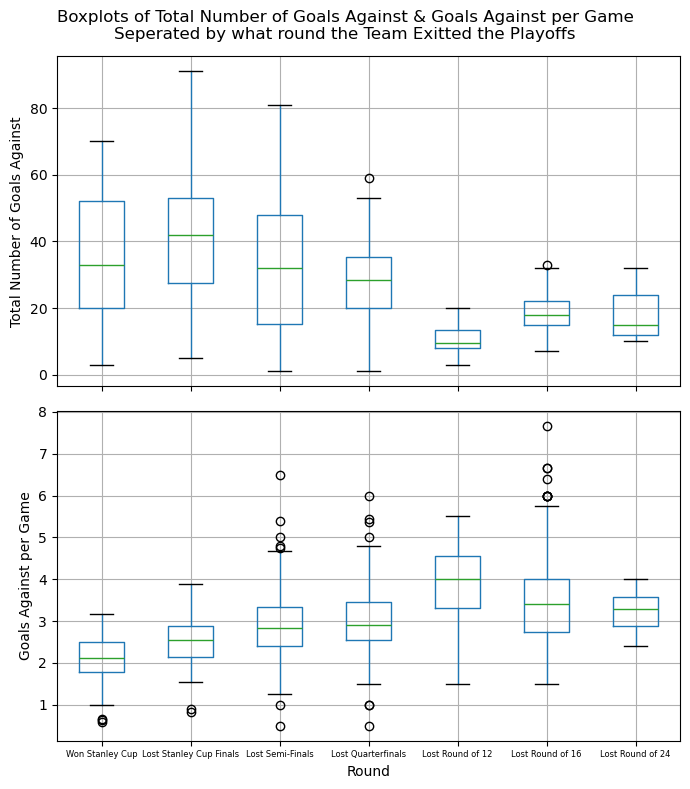

In [471]:
playoffs['against_per_game'] = playoffs['goals_against']/playoffs['games']
fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

playoffs.boxplot(column='goals_against',by='round',ax=axes[0])
playoffs.boxplot(column='against_per_game',by='round',ax=axes[1])

axes[0].set_title('')
axes[1].set_title('')

axes[0].set_xticklabels([])
axes[0].set_xlabel('')
axes[1].set_xlabel('Round')
axes[0].set_ylabel('Total Number of Goals Against')
axes[1].set_ylabel('Goals Against per Game')

axes[1].set_xticks(range(1, len(order2) + 1))
axes[1].set_xticklabels(order2, fontsize=6)

fig.suptitle('Boxplots of Total Number of Goals Against & Goals Against per Game\nSeperated by what round the Team Exitted the Playoffs')

plt.tight_layout()
plt.show()

These boxplots try to do the same things as the prior plots but using goals against instead. Specifically in the bottom plot, it is pretty easy to see the trend in this plot. The farther into the playoffs you go, the less goals are allowed by the teams.

# New Data Set

The following chunks of code are to add in a new dataset. This is one I made using info from Pro Hockey Reference and, as I mentioned earlier, is more for regular season results and stats. I almost immediately merged this dataset with the previous one I was using since most of the data I want to use would just go to help the findings from before.

Link to Pro Hockey Reference: https://www.hockey-reference.com/

Link to Spreadsheet (I might delete it, so sorry if it doesn't work in the future): https://docs.google.com/spreadsheets/d/1glVsDkbFpOj08qAKw-eMQrQK2Y4KHNqAw-t7_2Sf4Kk/edit?gid=0#gid=0

In [528]:
season = pd.read_csv("C:/Users/kurtg/Downloads/Untitled spreadsheet - Sheet1.csv")
season['Team'] = season['Team'].str.replace('*', '', regex=False).str.strip()
season['pts_percent'] = round(season['PTS']/(season['GP'] *2),3)
season['win_percent'] = round(season['W']/season['GP'],3)
season.columns = season.columns.str.lower()
season = season.rename(columns={'season':'year'})
season.head()

,year,lg,team,gp,w,l,t,ol,pts,pts_percent,win_percent
0,2022,NHL,Anaheim Ducks,82,31,37,NaN,14.0,76,0.463,0.378
1,2021,NHL,Anaheim Ducks,56,17,30,NaN,9.0,43,0.384,0.304
2,2020,NHL,Anaheim Ducks,71,29,33,NaN,9.0,67,0.472,0.408
3,2019,NHL,Anaheim Ducks,82,35,37,NaN,10.0,80,0.488,0.427
4,2018,NHL,Anaheim Ducks,82,44,25,NaN,13.0,101,0.616,0.537


In [327]:
playoff_season = pd.merge(playoffs, season, on=['year','team'])
playoff_season.head()

,rank,team,year,games,wins,losses,ties,shootout_wins,shootout_losses,win_loss_percentage,...,against_per_game,lg,gp,w,l,t,ol,pts,pts_percent,win_percent
0,1,Colorado Avalanche,2022,20,16,4,0,5,1,0.800,...,2.750000,NHL,82,56,19,NaN,7.0,119,0.726,0.683
1,2,Tampa Bay Lightning,2022,23,14,9,0,1,2,0.609,...,2.652174,NHL,82,51,23,NaN,8.0,110,0.671,0.622
2,3,New York Rangers,2022,20,10,10,0,1,2,0.500,...,2.900000,NHL,82,52,24,NaN,6.0,110,0.671,0.634
3,4,Edmonton Oilers,2022,16,8,8,0,1,2,0.500,...,3.687500,NHL,82,49,27,NaN,6.0,104,0.634,0.598
4,6,St. Louis Blues,2022,12,6,6,0,1,1,0.500,...,3.166667,NHL,82,49,22,NaN,11.0,109,0.665,0.598


In [328]:
team_16_ps = playoff_season.loc[playoff_season['num_teams'] == 16]
team_16_ps['round'] = team_16_ps['round'].cat.remove_unused_categories()
team_16_ps['round'] = pd.Categorical(team_16_ps['round'], categories=order, ordered=True)

bin_count = round(np.sqrt(len(team_16_ps)))

## Question 4: How does regular season record determine outcome?

While I don't have seeding data, I do have regular season data, which can be very helpful in determining how much those results go towards affecting the playoffs. Unfortunately, hockey is a bit different than other sports. It runs off a points system, with one win being worth 2 points, an overtime loss being worth 1 point, and a regulation loss being worth 0 points. Because of this, win-loss percentages in hockey don't really work the same as they do in other sports. I ultimately decided that, since I don't know how many overtime wins a team  achieved in a season, I would just use a win-percentage and compare that to the playoff's win-loss percentage despite the differences in rules.

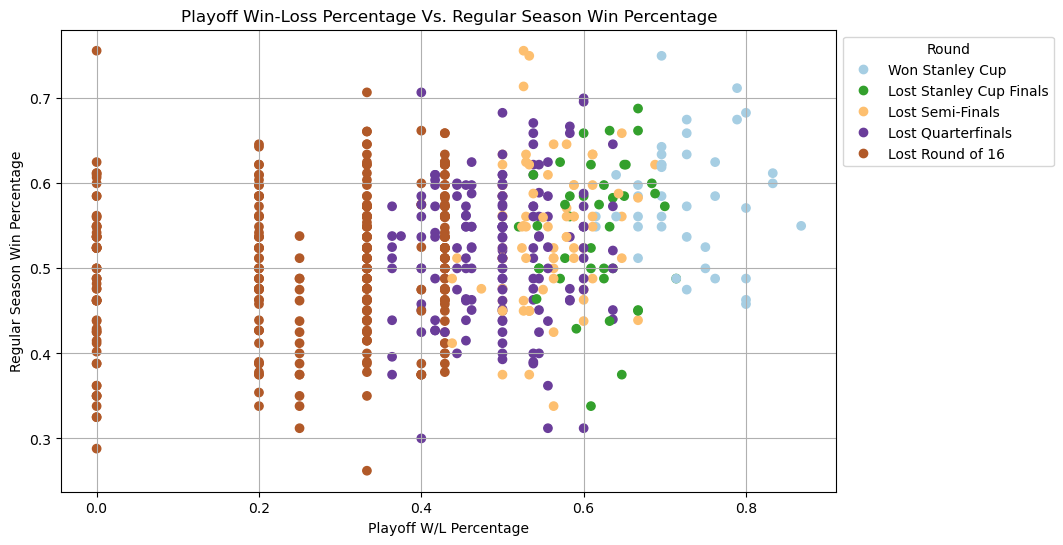

In [475]:
team_16_ps['round_code'] = team_16_ps['round'].cat.codes

plt.figure(figsize=(10, 6))

scatters = plt.scatter(team_16_ps['win_loss_percentage'],team_16_ps['win_percent'],
                       c=team_16_ps['round_code'],
                        cmap='Paired')

handles, _ = scatters.legend_elements()
labels = team_16_ps['round'].cat.categories

plt.legend(handles, labels, title='Round',loc='upper left',
           bbox_to_anchor=(1, 1))
plt.title('Playoff Win-Loss Percentage Vs. Regular Season Win Percentage')
plt.xlabel('Playoff W/L Percentage')
plt.ylabel('Regular Season Win Percentage')
plt.grid(True)
plt.show()

This is a bit of a messy plot, but it does give use some very interesting information. Firstly, no matter how good your record is, you can always be knocked out of the playoffs early. Look at how, even approaching the maximum win-percentages, there are teams with good records losing in the playoffs as early as the first round. You can also see how even teams with poor winning percentages (>0.5) can still make deep playoff runs and even win the Stanley Cup. This indicates that it's not about how much you win, but when you win that counts.

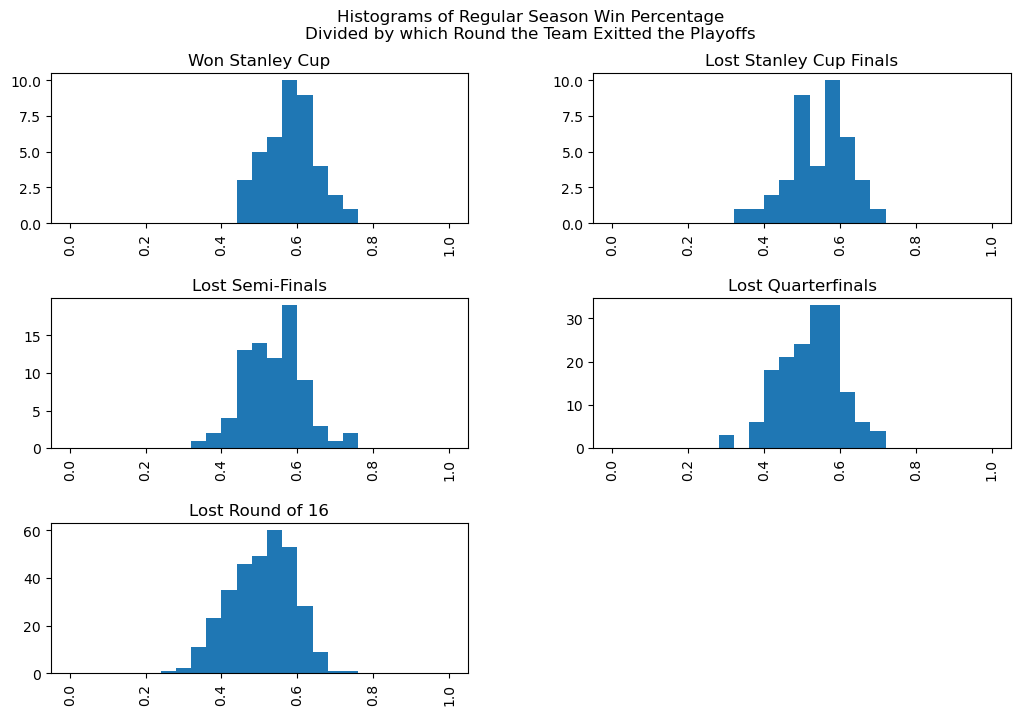

In [477]:
histograms3 = team_16_ps.hist(column='win_percent',by='round',
                bins=bin_count, figsize=(12,8), range=(0,1))

fig = histograms3.flatten()[0].get_figure()
fig.suptitle('Histograms of Regular Season Win Percentage\nDivided by which Round the Team Exitted the Playoffs')

plt.show()

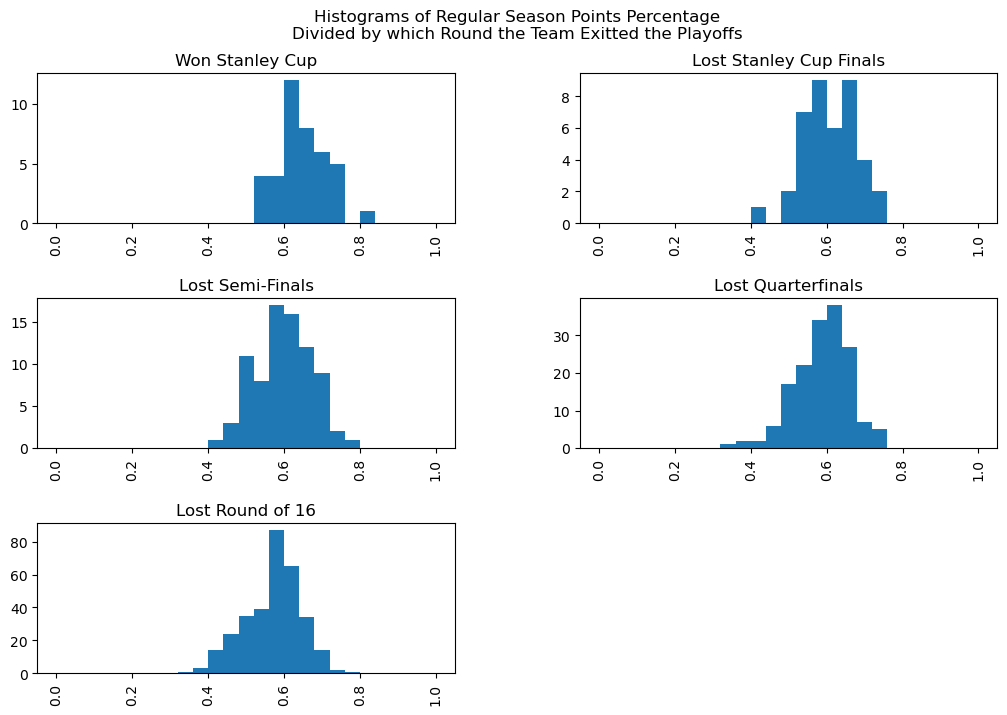

In [481]:
histograms4 = team_16_ps.hist(column='pts_percent',by='round',
                bins=bin_count, figsize=(12,8), range=(0,1))

fig = histograms4.flatten()[0].get_figure()
fig.suptitle('Histograms of Regular Season Points Percentage\nDivided by which Round the Team Exitted the Playoffs')

plt.show()

In [473]:
table = team_16_ps.groupby('round', observed=False)[['win_percent', 'pts_percent']].mean()
print(table)

print()
print(f'Difference between Stanley Cup Winner\'s Regular Season Win Percentage and Round of 16: {round(table.iloc[0,0]-table.iloc[4,0],3)}')
print(f'Difference between Stanley Cup Winner\'s Regular Season Points Percentage and Round of 16: {round(table.iloc[0,1]-table.iloc[4,1],3)}')

                         win_percent  pts_percent
round                                            
Won Stanley Cup             0.581175     0.644725
Lost Stanley Cup Finals     0.544325     0.608575
Lost Semi-Finals            0.538462     0.599413
Lost Quarterfinals          0.522596     0.588602
Lost Round of 16            0.505229     0.570818

Difference between Stanley Cup Winner's Regular Season Win Percentage and Round of 16: 0.076
Difference between Stanley Cup Winner's Regular Season Points Percentage and Round of 16: 0.074


The above histograms and table give us some interesting results. Look at how similar average win-percentage and points percentage are across every round. Having all of these be so similar to each other tells us, again, that it doesn't matter as much how well you do in the regular season just that you can win when it matters most.

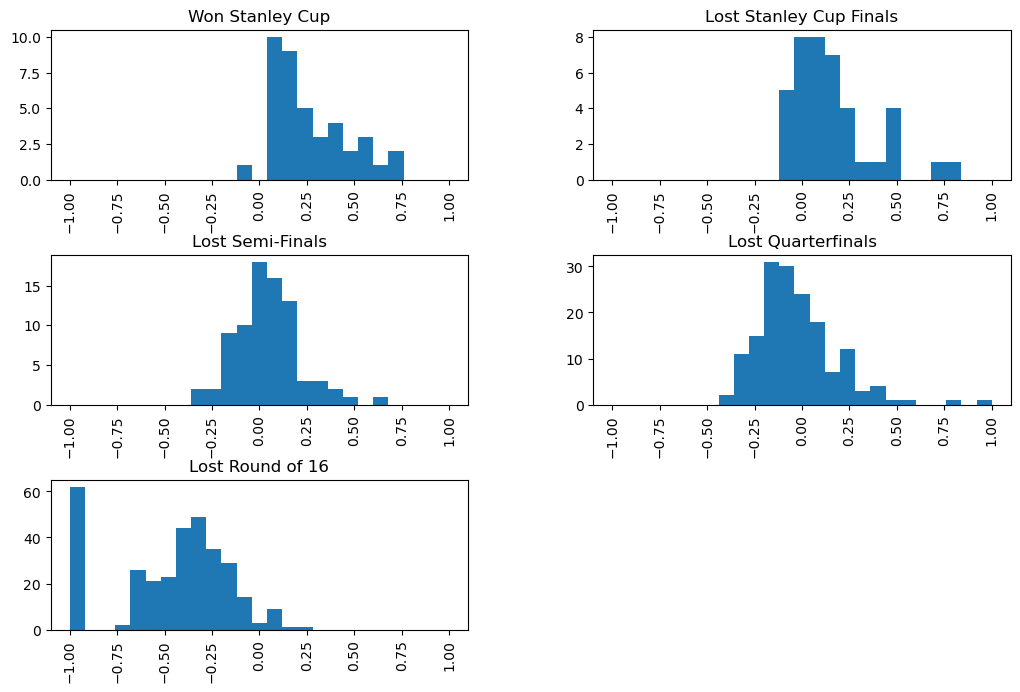

In [433]:
team_16_ps['win_percent_change'] = (team_16_ps['win_loss_percentage']-team_16_ps['win_percent'])/team_16_ps['win_percent']

team_16_ps.hist(column='win_percent_change',by='round',
                bins=bin_count, figsize=(12,8), range=(-1,1))
plt.show()

These histograms show the percent change in the win-percentage of the regular season compared to the post-season. Not too much to gather from these other than that, if you want to win the Stanley Cup, it is likely best to have a better playoff record than a regular season record.

In [337]:
team_16_ps.loc[team_16_ps['round'] == 'Won Stanley Cup']['win_percent_change'].idxmin()
stanley_cup_losing = team_16_ps.loc[148,['team','year','win_percent_change']]
print(f'The team that had a worse W/L record in the playoffs than in the regular season is the {stanley_cup_losing[1]} {stanley_cup_losing[0]}.')

The team that had a worse W/L record in the playoffs than in the regular season is the 2013 Chicago Blackhawks.


## Question 5: How do overtime losses/shootout losses determine outcomes?
### Does more OT losses decrease your odds in any substantial way

In [342]:
team_16_ps['otl_ratio'] = team_16_ps['ol']/team_16_ps['gp']
team_16_ps['otl_ratio_playoffs'] = team_16_ps['shootout_losses']/team_16_ps['games']

team_16_ps.groupby('round')[['ol','otl_ratio','shootout_losses','otl_ratio_playoffs']].mean()

,ol,otl_ratio,shootout_losses,otl_ratio_playoffs
round,,,,
Won Stanley Cup,7.650000,0.096302,1.475000,0.064914
Lost Stanley Cup Finals,7.600000,0.098389,1.475000,0.066071
Lost Semi-Finals,7.100000,0.088939,1.462500,0.083991
Lost Quarterfinals,7.560976,0.095807,1.273292,0.113465
Lost Round of 16,7.425150,0.093805,0.802508,0.150403


The table above tells us the mean number of overtime loses in the regular season (ol), the ratio to the number of games, and average number of overtime losses in the post season (shootout_losses), and their ratio to the number of games played.

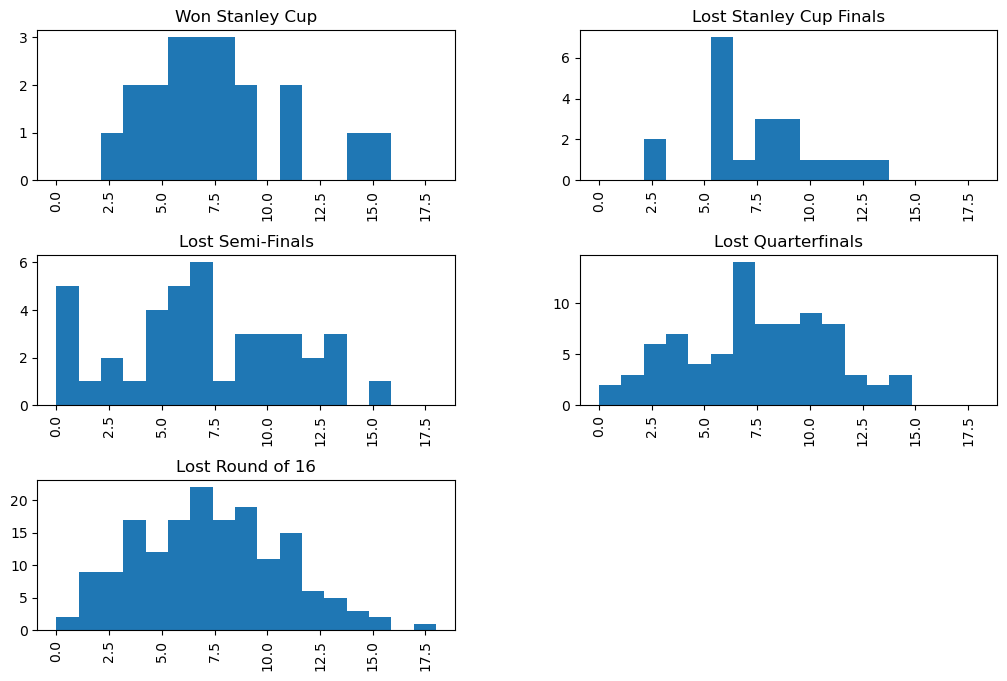

In [539]:
team_16_ps.hist(column='ol',by='round',
                bins=round(bin_count/1.5), figsize=(12,8),range=(0,18))
plt.show()

Since overtime losses are more beneficial in hockey than in any other sport, it is important to look at how they can help/hurt you in the most important moments. Judging by the means, most playoff contenders tend to have very similar numbers of overtime losses in the regular season, that being around 7-8. The histograms also help to back this up as they all have very similar distributions centered around the 5 - 10 mark. This indicates that excessive overtime losses, while not amzing as you are losing out on points, aren't horribly detrimental and don't indicate bad performances come playoff season.

## Conclusion

For the most part, my findings were rather trivial. Of course a better win-loss percentage will result in better playoff turnouts, of course more scoring will help improve a team's odds of winning it all. Still, it is important to point out what doesn't hurt teams. Regular season record, while highly important in making the playoffs, doesn't indicate how well you'll do in the playoffs, just like overtime losses. It goes to show that outcomes are based on current performance, not prior success. As well, considering the biggest pitfall of runner-ups was their goals allowed, it is important to emphasize that a good defense wins championships.

Like all sports, hockey is inherently unpredictable. You will never know who will win or lose, and no matter how big Goliath may seem, the Davids of the world still have a chance. No matter what my findings are, hockey will never be a "solved game," but it will always be of benefit to have indications of how a team will perform come the playoffs.